# 🔌 Jak działa API OpenAI

**Notebook do demo na żywo - Część 4: Podstawy API**

Ten notebook to demo na żywo do tej sesji. Pójdziemy krok po kroku:

1. Wyślemy najprostsze możliwe zapytanie do API
2. Obejrzymy **pełną, surową odpowiedź**, a nie tylko tekst
3. Przejdziemy po kolei przez **parametry** i zobaczymy, co każdy z nich faktycznie zmienia
4. Zobaczymy, jak wygląda **zużycie tokenów** i jak przekłada się na koszt
5. Zbudujemy prostego **agenta**: narzędzia + pętla + pamięć, na prawdziwych kursach walut z NBP
6. **Ćwiczenie:** samodzielnie rozbudujecie agenta o nowe narzędzie

Nic tu nie jest ukryte — każda komórka pokazuje prawdziwe zapytanie i prawdziwą odpowiedź.

## Krok 0 — Konfiguracja

In [ ]:
!pip install openai -q


In [ ]:
from openai import OpenAI
from getpass import getpass
import json

api_key = getpass("Paste the workshop API key: ")
client = OpenAI(api_key=api_key)

MODEL = "gpt-6-luna"


## Krok 1 — Najprostsze możliwe zapytanie

Zapytanie do API potrzebuje:
- **endpointu** (załatwia to za nas obiekt `client` — wskazuje na `https://api.openai.com/v1/chat/completions`)
- **klucza API** (ustawiliśmy go wyżej — po nim OpenAI wie, kto pyta i komu wystawić rachunek)
- **promptu / wiadomości** (`messages`) — czyli o co właściwie pytamy

I tyle. Poza `model` i `messages` żadne parametry nie są wymagane.

In [ ]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "In one sentence, what is an API?"}
    ]
)

# The convenient way to read the answer:
print(response.choices[0].message.content)


## Krok 2 — PEŁNA odpowiedź (nie tylko tekst)

To, co mamy wyżej, to tylko jedno pole, schowane w dużo większym obiekcie JSON. Zobaczmy wszystko, co faktycznie wróciło.

In [ ]:
# .model_dump() turns the response object into a plain dictionary we can inspect fully
full_response = response.model_dump()
print(json.dumps(full_response, indent=2))


### Co tu jest?
https://developers.openai.com/api/docs/guides/migrate-to-responses

| Pole | Co oznacza |
|---|---|
| `id` | Unikalny identyfikator tego konkretnego zapytania |
| `model` | Który model faktycznie wygenerował odpowiedź (może się lekko różnić od tego, o który prosiliśmy, np. wersja z datą) |
| `choices` | Lista wygenerowanych odpowiedzi|
| `choices[0].message.content` | Właściwy wygenerowany tekst — to, co wydrukowaliśmy w Kroku 1 |
| `choices[0].finish_reason` | **`stop`** = model skończył sam · **`length`** = odpowiedź ucięta przez limit tokenów · **`tool_calls`** = model chce wywołać narzędzie |
| `usage` | Liczba tokenów — od niej zależy koszt (zob. Krok 4) |
| `created` | Znacznik czasu zapytania |

👉 Wszystko, co model „robi”, to za każdym razem właśnie ten jeden obiekt JSON.

## Krok 3 — Parametry

Na razie użyliśmy tylko `model` i `messages`. Dodajmy pozostałe i zobaczmy, co faktycznie się zmienia.

### `temperature` — kreatywnie czy przewidywalnie

Zakres to mniej więcej od `0` do `2`. Niżej = bardziej przewidywalnie/deterministycznie. Wyżej = bardziej różnorodnie/kreatywnie.

Zadajmy **to samo pytanie dwa razy** — raz z `temperature=0`, raz z `temperature=1.8` — i porównajmy.

In [ ]:
prompt = [{"role": "user", "content": "Suggest a creative names for a coffee shop in the city center."}]

# GPT-6 models only accept `temperature` when reasoning is switched off (reasoning_effort="none")
low_temp = client.chat.completions.create(
    model=MODEL, messages=prompt, temperature=0, reasoning_effort="none"
)
high_temp = client.chat.completions.create(
    model=MODEL, messages=prompt, temperature=1.8, reasoning_effort="none"
)

print("temperature = 0   ->", low_temp.choices[0].message.content)
print("temperature = 1.8 ->", high_temp.choices[0].message.content)

# Try running this cell a few times — temperature=0 tends to give the same or very similar
# answer each time. temperature=1.8 will vary more.


### `max_tokens` / `max_completion_tokens` — jak długa może być odpowiedź

Ten parametr ogranicza długość odpowiedzi (w nowszych modelach nazywa się `max_completion_tokens`). Jeśli model nie skończy przed osiągnięciem limitu, `finish_reason` będzie miał wartość `"length"` zamiast `"stop"` — to sygnał, że odpowiedź została ucięta, a nie że model sam postanowił w tym miejscu skończyć.

In [ ]:
short_response = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Explain how photosynthesis works."}]
)

print("Text:", short_response.choices[0].message.content)
print("Finish reason:", short_response.choices[0].finish_reason)


In [ ]:
short_response = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Explain how photosynthesis works."}],
    max_completion_tokens=15,
    reasoning_effort="none"  # otherwise hidden reasoning tokens use up the 15-token budget and the text comes back empty
)

print("Text:", short_response.choices[0].message.content)
print("Finish reason:", short_response.choices[0].finish_reason)


### `model` — której wersji AI używamy

https://developers.openai.com/api/docs/models/compare
https://platform.claude.com/docs/en/models/overview
https://ai.google.dev/gemini-api/docs/models?hl=pl

Różne modele to różne kompromisy między kosztem, szybkością i możliwościami. Wyślijmy dokładnie ten sam prompt do różnych modeli i porównajmy.

**Porównanie cen u różnych dostawców** (USD za 1 mln tokenów, wejście / wyjście, stan na 23.09.2026)

| Półka | OpenAI | Anthropic | Google |
|---|---|---|---|
| Topowa (najdroższa) | GPT-6 Astra 10 / 50 | Claude Fable 5.1 10 / 50 · Claude Opus 5.5 4 / 20 | Gemini 3.1 Pro 2 / 12 |
| Średnia | GPT-6 Sol 2 / 10 | Claude Sonnet 5 2 / 10 | Gemini 3.8 Flash 0,75 / 3,75 (od stycznia 2027: 1,50 / 7,50) |
| Tania, do dużych wolumenów | GPT-6 Luna 0,10 / 0,50 | Claude Haiku 4.5 1 / 5 | Gemini 3.5 Flash-Lite 0,30 / 2,50 |

- **Tania półka** → klasyfikacja, ekstrakcja danych, tagowanie, krótkie streszczenia, routing
- **Średnia półka** → codzienne kodowanie, chatboty, RAG — obecnie najlepszy stosunek ceny do jakości
- **Topowa półka** → trudna, wieloetapowa praca agentowa, duże refaktoryzacje, złożone rozumowanie

Batch API = −50% u wszystkich trzech dostawców; wejście z cache jest ok. 90% tańsze. Ceny często się zmieniają — zawsze sprawdzajcie cennik dostawcy.

Poniżej porównujemy modele OpenAI: `gpt-6-luna`, `gpt-5.6-terra` (GPT-6 Terra jeszcze nie ma), `gpt-6-sol`, `gpt-6-astra`.

*(Podmieńcie na modele, które są faktycznie włączone na warsztatowym kluczu API.)*

In [ ]:
prompt = [{"role": "user", "content": "What's 17 * 24? Just the number."}]

for model_name in ["gpt-6-luna", "gpt-5.6-terra", "gpt-6-sol", "gpt-6-astra"]:
    r = client.chat.completions.create(model=model_name, messages=prompt)
    print(f"{model_name}: {r.choices[0].message.content}  (tokens used: {r.usage.total_tokens})")


In [ ]:
prompt = [{"role": "user", "content": """Below is a summary of last quarter's performance for three product lines. Read carefully — some numbers are more meaningful than they first appear.

- Electronics: Revenue grew 22% quarter-over-quarter. However, this growth includes a one-time bulk order from a single wholesale client that will not repeat next quarter.
- Home Goods: Revenue declined 4%. The entire decline happened in the first month, during a supplier shortage; the last two months returned to normal growth.
- Apparel: Revenue was flat (+0.5%). Customer count grew 15% over the same period.

Which product line should the team be MOST optimistic about heading into next quarter, and which should raise the MOST concern? Justify using only the underlying reasons above, not the headline percentages. Answer in exactly two sentences — one for 'most optimistic', one for 'most concerning'. Do not mention any percentages in your answer."""}]

for model_name in ["gpt-6-luna", "gpt-5.6-terra", "gpt-6-sol", "gpt-6-astra"]:
    r = client.chat.completions.create(model=model_name, messages=prompt)
    print(f"--- {model_name} (tokens used: {r.usage.total_tokens}) ---")
    print(r.choices[0].message.content)
    print()

## Krok 4 — Zużycie tokenów i koszt

Każde zapytanie zwraca obiekt `usage`. To za niego faktycznie płacimy — nie za „jedno wywołanie API”, tylko za liczbę tokenów na wejściu i wyjściu.

In [ ]:
import time
import pandas as pd

prompt = [{"role": "user", "content": """Szukam mieszkania do wynajęcia na DOKŁADNIE 6 miesięcy — potem przeprowadzam się do innego miasta. Mam trzy oferty:

- Mieszkanie A: 3 100 zł miesięcznie, wszystkie opłaty wliczone. Umowa na minimum 6 miesięcy.
- Mieszkanie B: 2 600 zł miesięcznie + 450 zł opłat miesięcznie. Umowa na 12 miesięcy; wcześniejsze zerwanie umowy kosztuje karę równą dwóm miesięcznym czynszom najmu (bez opłat).
- Mieszkanie C: 2 800 zł miesięcznie, wszystkie opłaty wliczone. Umowa na 6 miesięcy, ale na start trzeba zapłacić jednorazową prowizję agencji w wysokości jednego miesięcznego czynszu.

Kaucje są zwrotne, więc je pomiń. Która oferta będzie mnie łącznie kosztowała NAJMNIEJ, a która NAJWIĘCEJ za cały 6-miesięczny pobyt? Odpowiedz dokładnie w dwóch zdaniach i podaj łączne kwoty w złotych."""}]

# Correct answer:
#   A = 6 x 3100             = 18 600 zł  <- cheapest
#   B = 6 x 3050 + 2 x 2600  = 23 500 zł  <- most expensive (lowest rent = the trap!)
#   C = 7 x 2800             = 19 600 zł

# USD per 1M tokens: (input, output). Check https://openai.com/api/pricing/ before the workshop.
# Order: oldest -> newest generation, and weakest -> strongest within each generation.
PRICES = {
    # GPT-4.x (no hidden reasoning)
    "gpt-4o-mini":   (0.15, 0.60),
    "gpt-4.1-nano":  (0.10, 0.40),
    "gpt-4.1-mini":  (0.40, 1.60),
    "gpt-4.1":       (2.00, 8.00),
    # GPT-5.x
    "gpt-5-nano":    (0.05, 0.40),
    "gpt-5-mini":    (0.25, 2.00),
    "gpt-5.4-mini":  (0.75, 4.50),
    "gpt-5.6-terra": (2.00, 12.00),
    # GPT-6 (September 2026)
    "gpt-6-luna":    (0.10, 0.50),
    "gpt-6-sol":     (2.00, 10.00),
    "gpt-6-astra":   (10.00, 50.00),
}

rows = []
for model_name, (price_in, price_out) in PRICES.items():
    print(f"⏳ {model_name} ...", end=" ")
    try:
        start = time.perf_counter()
        r = client.chat.completions.create(model=model_name, messages=prompt)
        seconds = time.perf_counter() - start
    except Exception as e:  # model not enabled on this key / already retired
        print(f"skipped ({type(e).__name__})")
        continue
    print("ok")

    usage = r.usage
    answer = (r.choices[0].message.content or "").strip()
    cost = usage.prompt_tokens / 1e6 * price_in + usage.completion_tokens / 1e6 * price_out

    rows.append({
        "Model": model_name,
        "Tokeny input": usage.prompt_tokens,
        "Tokeny output": usage.completion_tokens,
        "Czas [s]": seconds,
        "Koszt zapytania [USD]": cost,
        "Koszt 1000 zapytań [USD]": cost * 1000,
        "Odpowiedź modelu": answer,
    })

# Keep the order from PRICES (no sorting by cost)
results = pd.DataFrame(rows)

display(
    results.style
    .format({
        "Czas [s]": "{:.1f}",
        "Koszt zapytania [USD]": "{:.6f}",
        "Koszt 1000 zapytań [USD]": "{:.2f}",
    })
    .set_properties(subset=["Odpowiedź modelu"], **{
        "white-space": "pre-wrap",   # keep line breaks, wrap long answers
        "text-align": "left",
        "min-width": "400px",
    })
)

Czy można by było jeszcze jakoś inaczej podejść do tych kosztów? Rezygnacja w 4 miesiącu z mieszkania B? Jedna z odpowiedzi podczas testów:
2	gpt-4.1-mini	265	154	2.2	0.000352	0.35	Najmniej zapłacisz za mieszkanie B: 6 x (2 600 + 450) = 18 300 zł, mimo że umowa jest na 12 miesięcy, kara za wcześniejsze zerwanie nie będzie naliczona, jeśli się rozwiążesz po 6 miesiącach zgodnie z umową (zakładam, że możesz rozwiązać po 6 miesiącach lub porozumienie z właścicielem). Najwięcej kosztować Cię będzie mieszkanie C: 6 x 2 800 + 2 800 (prowizja) = 19 600 zł, a mieszkanie A wyniesie 6 x 3 100 = 18 600 zł.

## Krok 5 — od chatbota do agenta

Do tej pory model umiał tylko **odpowiadać tekstem**. Agent potrafi więcej: **sięga po narzędzia** i **działa w pętli**, aż zadanie będzie zrobione.

Zbudujemy małego asystenta walutowego z trzema narzędziami:

| Narzędzie | Co robi |
|---|---|
| `get_rates` | czyta kursy walut z pliku `rates.csv` |
| `read_memory` | czyta notatki z pliku `memory.md` |
| `save_memory` | dopisuje notatkę do `memory.md` |

Najpierw pobierzemy prawdziwe kursy z API NBP (darmowe, bez klucza) i zapiszemy je do pliku CSV — agent będzie analizował dane z tego pliku.

Całość to 4 kroki: **dane do CSV → narzędzia → opis narzędzi dla modelu → pętla agenta.**

### 5.1 Dane — pobieramy kursy do pliku CSV

Jednym zapytaniem do API NBP pobieramy kursy **wszystkich walut z ostatnich 30 notowań** i zapisujemy je do `rates.csv`. Otwórzcie ten plik w przeglądarce plików Colaba (ikonka folderu po lewej) — to zwykła tabelka.

Agent nie będzie łączył się z internetem — będzie czytał dane z tego pliku.

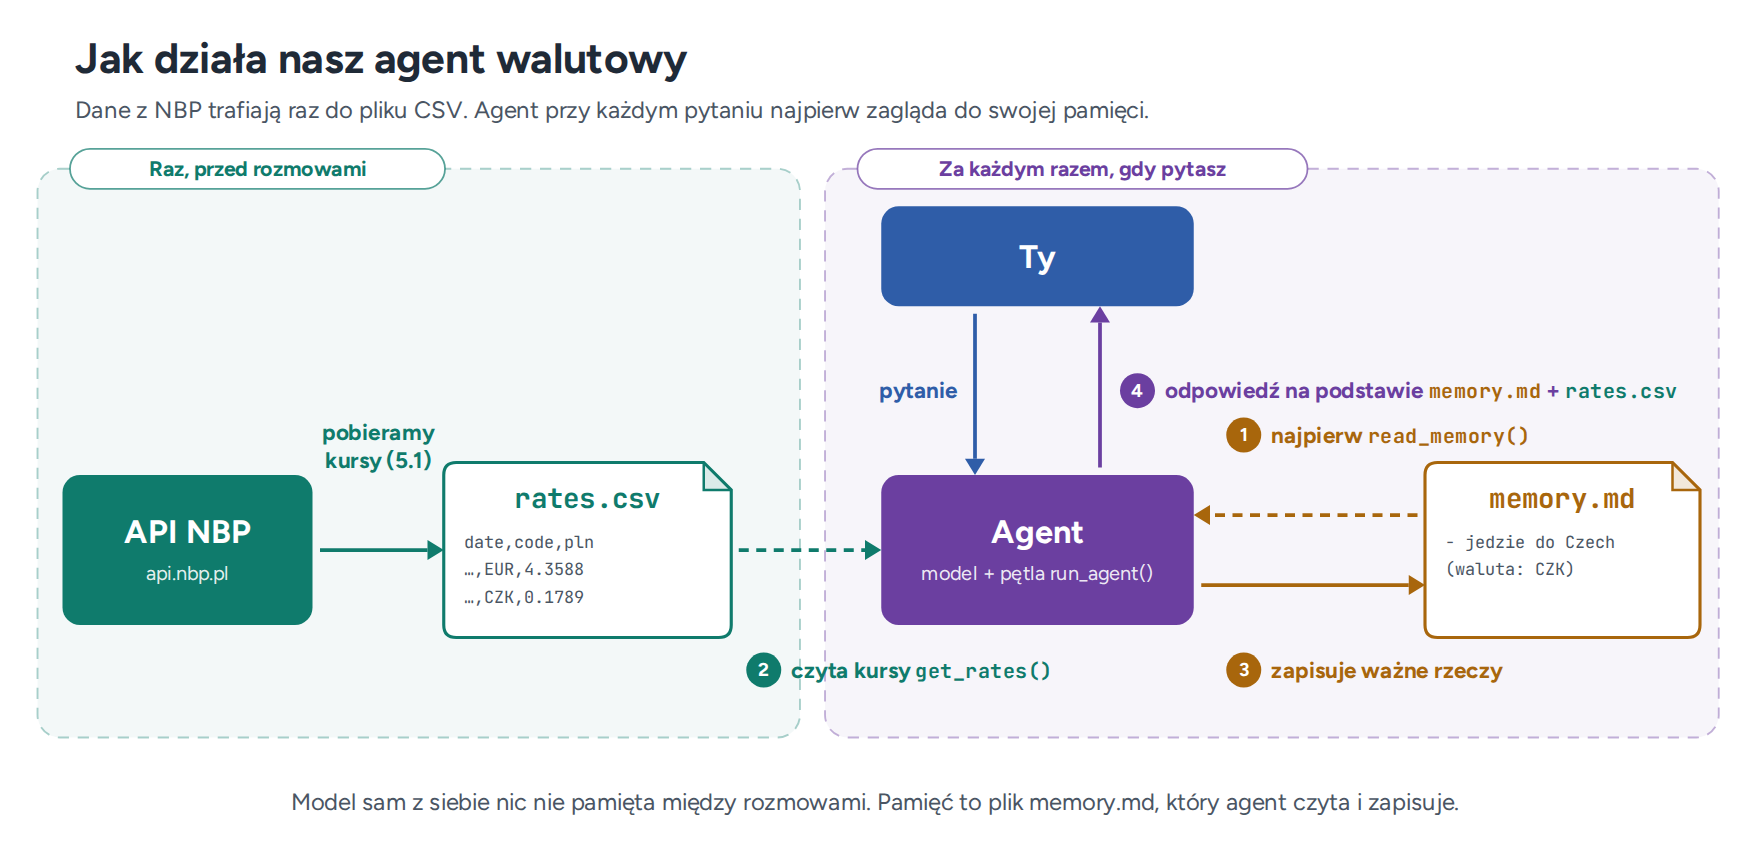

In [ ]:
import pandas as pd
import requests

RATES_FILE = "rates.csv"

# One request = the last 30 NBP tables with ALL currencies
url = "https://api.nbp.pl/api/exchangerates/tables/a/last/30/?format=json"
tables = requests.get(url).json()

rows = []
for table in tables:
    for rate in table["rates"]:
        rows.append({
            "date": table["effectiveDate"],
            "code": rate["code"],
            "currency": rate["currency"],
            "pln": rate["mid"],
        })

pd.DataFrame(rows).to_csv(RATES_FILE, index=False)
print(f"Saved {len(rows)} rows to {RATES_FILE}")

pd.read_csv(RATES_FILE).head(10)

### 5.2 Narzędzia = zwykłe funkcje w Pythonie

Nic tu nie ma wspólnego z AI — `get_rates` to zwykłe filtrowanie tabelki w pandas. Sprawdźmy, czy działają, zanim oddamy je modelowi.

In [ ]:
import json

MEMORY_FILE = "memory.md"


def get_rates(currency):
    """Official NBP exchange rates of a currency in PLN, read from rates.csv."""
    df = pd.read_csv(RATES_FILE)
    rows = df[df["code"] == currency.upper()].sort_values("date")
    if rows.empty:
        return {"error": f"No data for currency '{currency}' in {RATES_FILE}"}
    return {
        "currency": currency.upper(),
        "rates": rows[["date", "pln"]].to_dict("records"),
    }


def read_memory():
    try:
        with open(MEMORY_FILE, encoding="utf-8") as f:
            return {"memory": f.read()}
    except FileNotFoundError:
        return {"memory": "(empty)"}


def save_memory(note):
    with open(MEMORY_FILE, "a", encoding="utf-8") as f:
        f.write(f"- {note}\n")
    return {"status": "saved"}


print(get_rates("EUR"))

### 5.3 Opis narzędzi dla modelu

Model **nie widzi naszego kodu**. Widzi tylko nazwę, opis i parametry — i na tej podstawie sam decyduje, *kiedy* po które narzędzie sięgnąć.

In [ ]:
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_rates",
            "description": "Get official NBP exchange rates of a currency in Polish złoty (PLN) from the last 30 quotes, read from rates.csv.",
            "parameters": {
                "type": "object",
                "properties": {"currency": {"type": "string", "description": "Currency code, e.g. EUR, USD, CZK"}},
                "required": ["currency"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "read_memory",
            "description": "Read notes about the user saved in earlier conversations.",
            "parameters": {"type": "object", "properties": {}},
        },
    },
    {
        "type": "function",
        "function": {
            "name": "save_memory",
            "description": "Save a short note about the user, so you remember it in future conversations.",
            "parameters": {
                "type": "object",
                "properties": {"note": {"type": "string"}},
                "required": ["note"],
            },
        },
    },
]

# Name the model uses -> the real Python function
TOOL_FUNCTIONS = {"get_rates": get_rates, "read_memory": read_memory, "save_memory": save_memory}

### 5.4 Pętla agenta

To jest całe „serce” agenta:

1. Wysyłamy modelowi pytanie + listę narzędzi.
2. Model odpowiada: **„uruchom mi narzędzie X”** → my je uruchamiamy i odsyłamy wynik → wracamy do punktu 1.
3. Model odpowiada **zwykłym tekstem** → koniec.

> **Pytanie → model prosi o narzędzie → my je uruchamiamy → model widzi wynik → ... → odpowiedź**

In [ ]:
SYSTEM_PROMPT = """You are a helpful currency assistant with long-term memory.
Follow these steps in every conversation:
1. First, call read_memory.
2. If the user mentions anything about themselves (a trip, a country, a currency, a plan or preference)
   that is not already in memory, call save_memory BEFORE answering. The user does not have to ask you to remember it.
   Example: "I'm going to Italy" -> save_memory("User is going to Italy (currency: EUR)").
3. Use get_rates for any exchange rate. Never guess rates.
4. Answer in Polish, in 2-3 sentences."""


def run_agent(question):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    print("👤", question, "\n")

    for step in range(5):  # safety limit, so the agent can't loop forever
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=TOOLS,
            reasoning_effort="none",  # required for tool calling with GPT-6 Luna/Sol
        )
        message = response.choices[0].message
        messages.append(message)

        # No tool requested -> this is the final answer
        if not message.tool_calls:
            print("\n🤖", message.content)
            return

        # The model asked for tools -> we run them and send back the results
        for tool_call in message.tool_calls:
            name = tool_call.function.name
            args = json.loads(tool_call.function.arguments)
            result = TOOL_FUNCTIONS[name](**args)
            print(f"🔧 {name}({args}) -> {str(result)[:100]}")
            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": json.dumps(result, ensure_ascii=False),
            })

### 5.5 Demo — rozmowa nr 1

Zaczynamy z pustą pamięcią. Zwróćcie uwagę: nie podajemy kodu waluty, a agent sam wie, że korona czeska to `CZK`.

In [ ]:
import os
if os.path.exists(MEMORY_FILE):
    os.remove(MEMORY_FILE)  # start with an empty memory

run_agent("W przyszłym miesiącu jadę do Czech. Jaki jest aktualny kurs korony czeskiej?")

In [ ]:
# What did the agent save? It's just a text file (you can also open it in the Colab file browser)
print(read_memory()["memory"])

### 5.6 Demo — rozmowa nr 2 (zupełnie nowa)

Nowa rozmowa = model **nic nie pamięta** z poprzedniej. Pytamy o „moją walutę”, w ogóle jej nie nazywając. Jedyne, co łączy obie rozmowy, to plik `memory.md`.

In [ ]:
run_agent("Jak zmieniał się ostatnio kurs waluty?")

### Co się właśnie stało?

- **Model nie wymyślił kursów** — wszystkie liczby przyszły z pliku `rates.csv` (a do pliku — z API NBP).
- **Model sam nie uruchamia kodu.** On tylko prosi o narzędzie, a uruchamia je nasza pętla.
- **Agent sam wybrał kolejność kroków:** najpierw pamięć, potem kursy, potem zapis.
- **Pamięć to nie magia** — to zwykły plik tekstowy, który agent czyta i zapisuje przez narzędzia.
- **Zapis do pliku to akcja w świecie.** Gdyby narzędziem było `send_email` albo `delete_file` — czy agent powinien najpierw zapytać o zgodę?

## Podsumowanie

| Element | Co zobaczyliśmy |
|---|---|
| **Zapytanie** | endpoint + klucz API + wiadomości (prompt) + parametry |
| **Parametry** | `model`, `temperature`, `max_tokens`, a teraz także `tools` |
| **Odpowiedź** | zawsze obiekt JSON — tekst, `finish_reason`, `usage`, a przy narzędziach `tool_calls` |
| **Koszt** | liczba tokenów input + output — a każdy krok agenta to kolejne zapytanie |
| **Narzędzia** | zwykłe funkcje + opis; model prosi, nasz kod wykonuje (np. czyta plik CSV) |
| **Pętla agenta** | pytamy model → uruchamiamy narzędzia → odsyłamy wyniki → aż do odpowiedzi |
| **Pamięć** | plik, który agent czyta i zapisuje przez narzędzia |